# Condition Monitoring of a Hydraulic System

This project focuses on **predicting the health condition of a hydraulic test rig** using sensor data collected during cyclic load operations. The dataset was originally published by ZeMA gGmbH and contains readings from 17 sensors — including pressure, temperature, vibration, motor power, volume flow, and virtual cooling metrics — sampled at different frequencies (1 Hz, 10 Hz, and 100 Hz).

**Goal:** Build a classification model that can predict the **cooler condition** (close to total failure, reduced efficiency, or full efficiency) based on the sensor readings.

We'll walk through the following steps:
1. Loading and exploring the dataset
2. Visualizing class distributions and feature relationships
3. Preparing the data (scaling, encoding)
4. Training an SGD classifier
5. Evaluating the model and making predictions

## Step 1: Import Libraries

We start by bringing in the essential Python libraries:
- **NumPy & Pandas** — for numerical operations and data handling
- **Seaborn & Matplotlib** — for creating visualizations
- **Scikit-learn** — for preprocessing, splitting data, and building the classifier

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDClassifier

## Step 2: Load the Dataset

The dataset (`Final.csv`) contains sensor readings from a hydraulic test rig. Each row represents one 60-second load cycle, and the columns hold aggregated values from 17 different sensors along with target condition labels for the cooler, valve, pump, and accumulator.

In [2]:
# Read the processed CSV file into a DataFrame
df = pd.read_csv("Final.csv")

# Quick look at the first 5 rows to understand the structure
df.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator,Stable_Flag
0,160.673492,109.466914,1.991475,0.0,9.842170,9.728098,35.621983,40.978767,38.471017,31.745250,...,2538.929167,0.576950,39.601350,1.862750,59.157183,3.0,100.0,0.0,130.0,1.0
1,160.603320,109.354890,1.976234,0.0,9.635142,9.529488,36.676967,41.532767,38.978967,34.493867,...,2531.498900,0.565850,25.786433,1.255550,59.335617,3.0,100.0,0.0,130.0,1.0
2,160.347720,109.158845,1.972224,0.0,9.530548,9.427949,37.880800,42.442450,39.631950,35.646150,...,2519.928000,0.576533,22.218233,1.113217,59.543150,3.0,100.0,0.0,130.0,1.0
3,160.188088,109.064807,1.946576,0.0,9.438827,9.337430,38.879050,43.403983,40.403383,36.579467,...,2511.541633,0.569267,20.459817,1.062150,59.794900,3.0,100.0,0.0,130.0,1.0
4,160.000472,108.931434,1.922707,0.0,9.358762,9.260636,39.803917,44.332750,41.310550,37.427900,...,2503.449500,0.577367,19.787017,1.070467,59.455267,3.0,100.0,0.0,130.0,1.0


## Step 3: Explore the Data

Let's take a closer look at what columns are available, get summary statistics, and check data types. This helps us understand the scale of each feature and whether there's any missing data.

In [3]:
# List all column names in the dataset
columns = df.columns
columns

Index(['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'TS1', 'TS2', 'TS3', 'TS4',
       'FS1', 'FS2', 'EPS1', 'VS1', 'CE', 'CP', 'SE', 'Cooler_Condition',
       'Valve_Condition', 'Internal_Pump_Leakage', 'Hydraulic_Accumulator',
       'Stable_Flag'],
      dtype='object')

In [4]:
# We only want the sensor/feature columns — drop the target labels so we have a clean feature list
columns = columns.drop(['Cooler_Condition', 'Internal_Pump_Leakage', 'Valve_Condition', 'Hydraulic_Accumulator', 'Stable_Flag'])

In [5]:
# Summary statistics — gives us the mean, std, min/max for each numeric column
df.describe()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator,Stable_Flag
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,160.485315,109.379906,1.753227,2.600266,9.163320,9.079363,45.424567,50.365979,47.662121,40.735654,...,2495.509203,0.613315,31.299077,1.808399,55.287900,41.240816,90.693878,0.669388,107.199546,0.342857
std,4.699425,4.986585,0.251902,4.279355,0.576296,0.549589,7.991933,7.396254,7.451888,8.107878,...,73.836682,0.060260,11.575330,0.278263,8.960189,42.383143,10.681802,0.817233,16.435848,0.474772
min,155.391547,104.406307,0.840252,0.000000,8.365801,8.321527,35.313783,40.859400,38.245733,30.390800,...,2361.747267,0.524367,17.555983,1.062150,18.276617,3.000000,73.000000,0.000000,90.000000,0.000000
25%,158.100195,106.962382,1.729733,0.000000,8.547239,8.487167,36.237150,41.864183,39.123183,31.272567,...,2442.933467,0.555100,20.084650,1.550100,56.270183,3.000000,80.000000,0.000000,90.000000,0.000000
50%,158.960895,107.730169,1.779630,0.000000,9.115781,9.031516,44.836650,49.780583,47.070250,40.429050,...,2480.926633,0.610183,27.392533,1.739683,58.758150,20.000000,100.000000,0.000000,100.000000,0.000000
75%,161.000735,109.421612,1.932047,3.503266,9.844351,9.729276,54.104317,58.584467,55.694433,49.409500,...,2548.211467,0.649850,46.677383,2.148483,59.656900,100.000000,100.000000,1.000000,130.000000,1.000000
max,180.922708,131.589089,2.023398,10.207068,9.978511,9.856591,57.899283,61.958467,59.423167,53.060417,...,2740.641000,0.839067,47.903667,2.840100,60.755300,100.000000,100.000000,2.000000,130.000000,1.000000


In [6]:
# Check data types and non-null counts — good to confirm there are no missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PS1                    2205 non-null   float64
 1   PS2                    2205 non-null   float64
 2   PS3                    2205 non-null   float64
 3   PS4                    2205 non-null   float64
 4   PS5                    2205 non-null   float64
 5   PS6                    2205 non-null   float64
 6   TS1                    2205 non-null   float64
 7   TS2                    2205 non-null   float64
 8   TS3                    2205 non-null   float64
 9   TS4                    2205 non-null   float64
 10  FS1                    2205 non-null   float64
 11  FS2                    2205 non-null   float64
 12  EPS1                   2205 non-null   float64
 13  VS1                    2205 non-null   float64
 14  CE                     2205 non-null   float64
 15  CP  

## Step 4: Visualize Target Variable Distributions

Before modeling, it's helpful to see how the target labels are distributed. If one class heavily dominates, we might face class imbalance issues. We'll also look at how the Stable Flag relates to each condition.

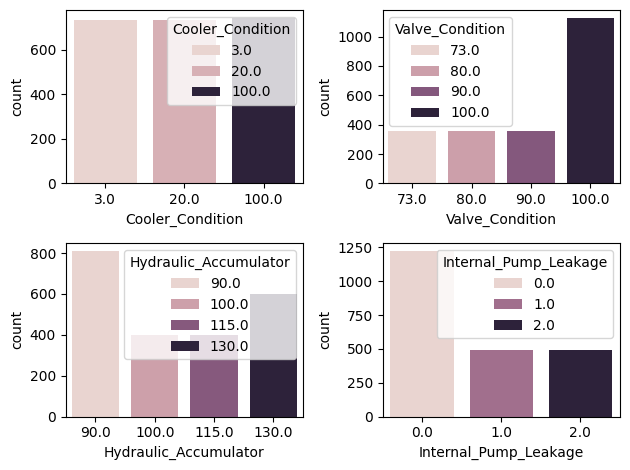

In [7]:
# Count plots for each target variable — shows how many samples fall into each condition category
plt.subplot(2, 2, 1)
sns.countplot(x='Cooler_Condition', data=df, hue='Cooler_Condition')
plt.subplot(2, 2, 2)
sns.countplot(x='Valve_Condition', data=df, hue='Valve_Condition')
plt.subplot(2, 2, 3)
sns.countplot(x='Hydraulic_Accumulator', data=df, hue='Hydraulic_Accumulator')
plt.subplot(2, 2, 4)
sns.countplot(x='Internal_Pump_Leakage', data=df, hue='Internal_Pump_Leakage')

plt.tight_layout()

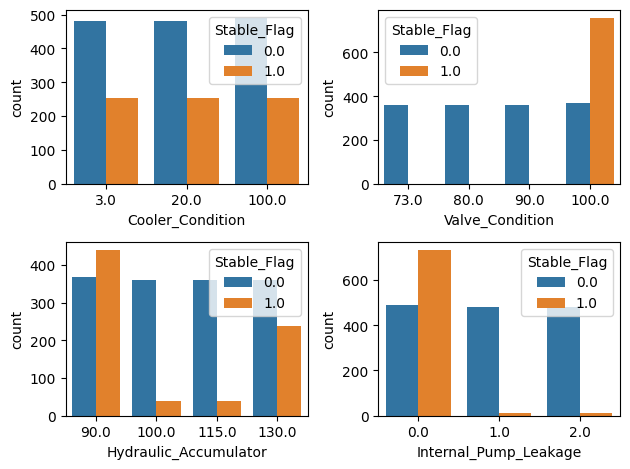

In [8]:
# Same conditions, but now colored by Stable_Flag to see if unstable cycles skew any class
plt.subplot(2, 2, 1)
sns.countplot(x='Cooler_Condition', data=df, hue='Stable_Flag')
plt.subplot(2, 2, 2)
sns.countplot(x='Valve_Condition', data=df, hue='Stable_Flag')
plt.subplot(2, 2, 3)
sns.countplot(x='Hydraulic_Accumulator', data=df, hue='Stable_Flag')
plt.subplot(2, 2, 4)
sns.countplot(x='Internal_Pump_Leakage', data=df, hue='Stable_Flag')

plt.tight_layout()

### Strip Plots: Feature vs Stable Flag

Strip plots give us a sense of how each sensor reading varies for stable vs. unstable cycles. If a feature shows clear separation between the two groups, it's likely a useful predictor.

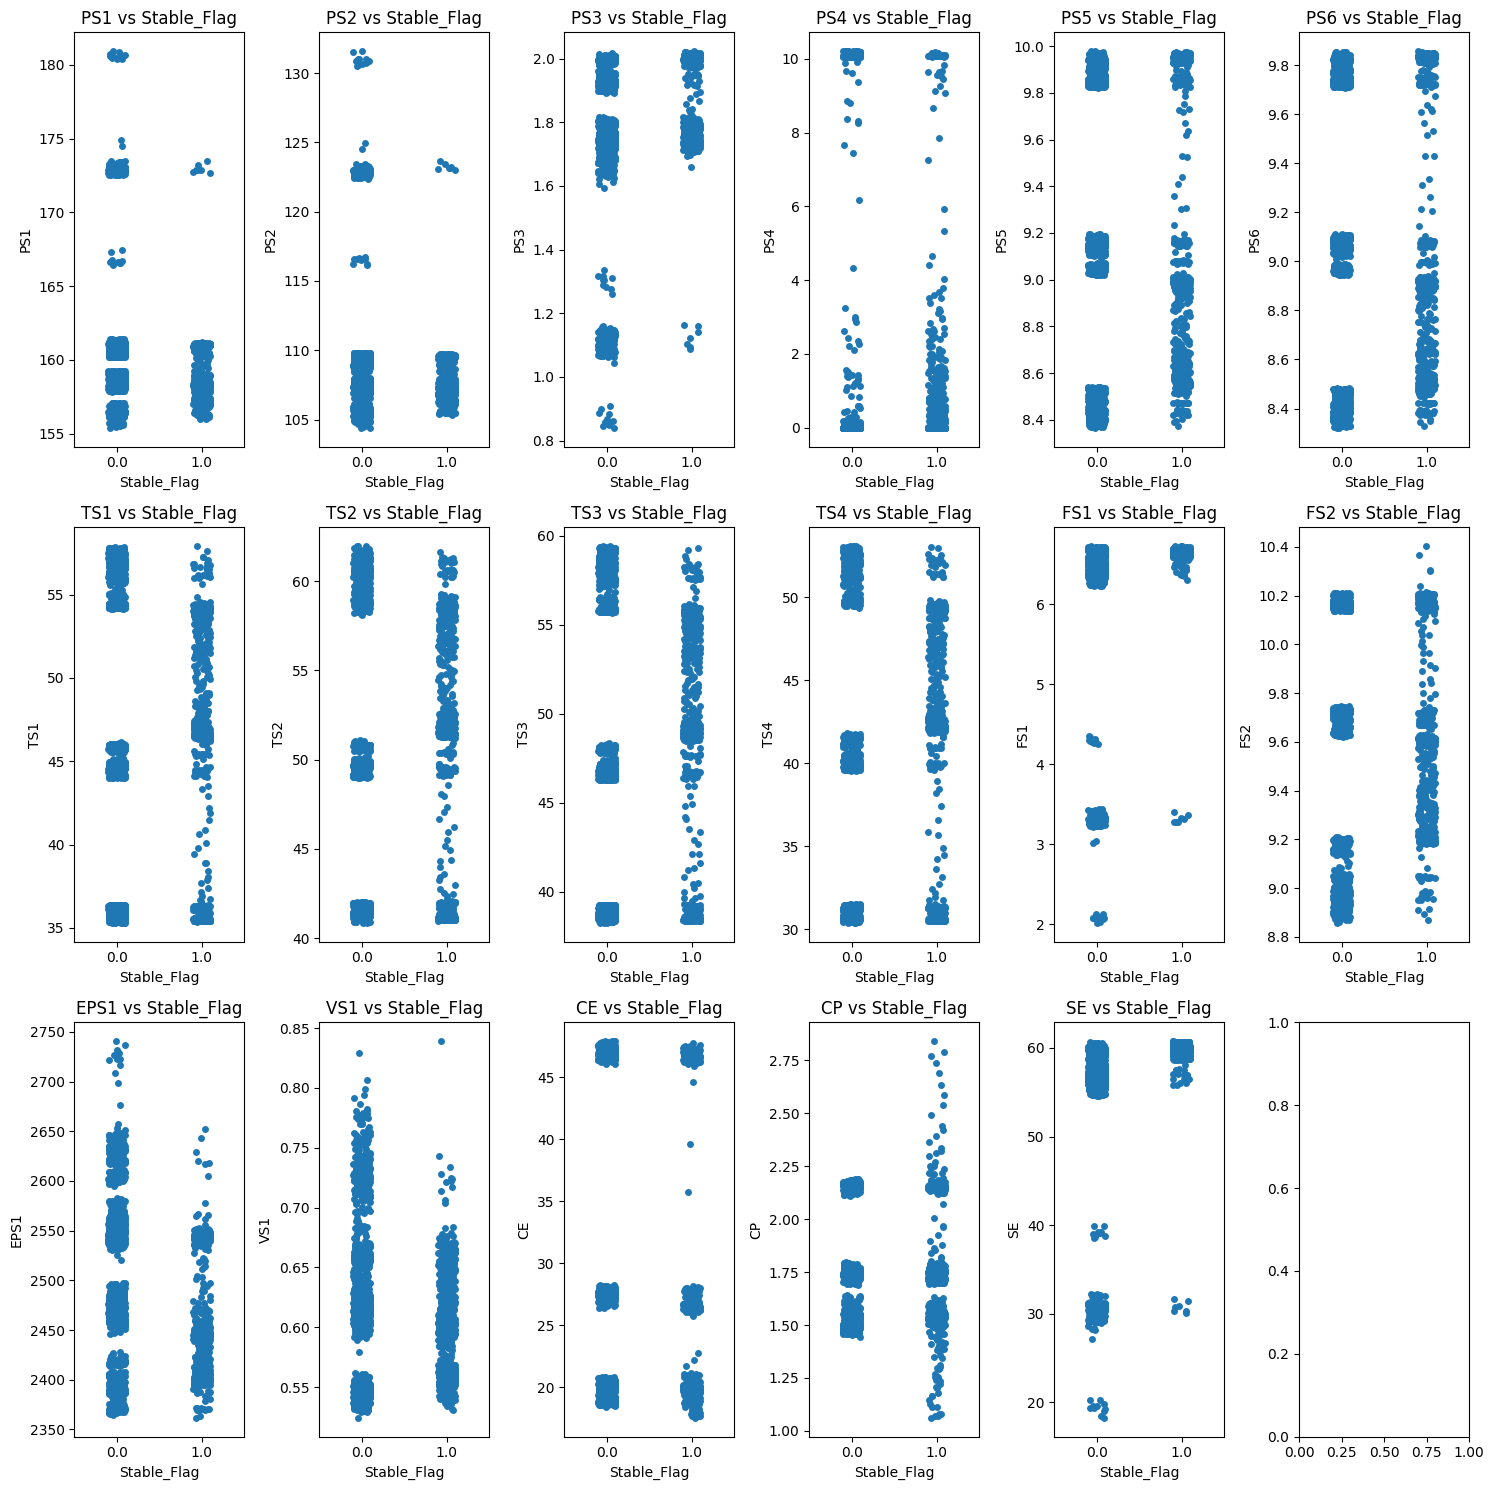

In [9]:
# Create a grid of strip plots — one for each sensor feature vs the Stable_Flag
rows = 6
cols = 3
fig, ax = plt.subplots(cols, rows, figsize=(15, 15))
ax = ax.flatten()

for i, col_name in enumerate(columns):
    sns.stripplot(x='Stable_Flag', y=col_name, data=df, ax=ax[i])
    ax[i].set_title(f'{col_name} vs Stable_Flag')

plt.tight_layout()

### Correlation Heatmap

A correlation matrix helps us identify relationships between features. Highly correlated features might carry redundant information, and strong correlations with targets point to useful predictors.

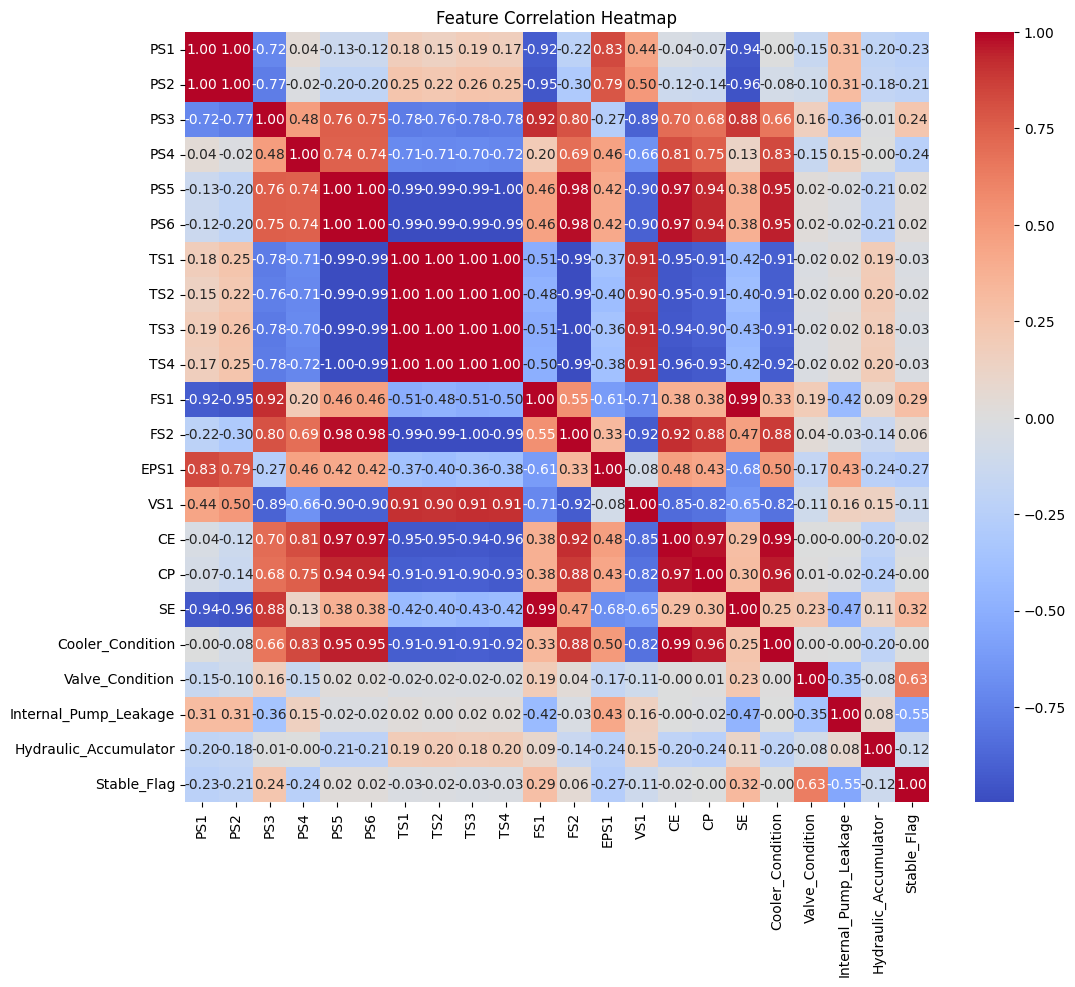

In [10]:
# Compute the pairwise correlation between all numeric columns
corr = df.corr()

# Plot it as a heatmap with annotations for easy reading
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Step 5: Prepare Data for Cooler Condition Prediction

From here on, we'll focus specifically on predicting the **Cooler Condition**. We'll:
1. Drop unrelated target columns (Valve, Pump Leakage, Accumulator) so they don't leak information
2. Scale the sensor features using StandardScaler (zero mean, unit variance)
3. Encode the target labels into numeric form for the classifier

In [11]:
# Quick sanity check — look at the last few rows before we start modifying the DataFrame
df.tail()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator,Stable_Flag
2200,161.227572,109.779581,2.001438,10.202473,9.972037,9.850361,35.313783,40.874800,38.269267,30.404733,...,2543.911033,0.550833,46.628517,2.160600,59.03310,100.0,100.0,0.0,90.0,0.0
2201,161.206070,109.787481,1.998781,10.197919,9.966184,9.844854,35.321600,40.868883,38.268250,30.416233,...,2543.411333,0.547483,46.689817,2.151450,59.06800,100.0,100.0,0.0,90.0,0.0
2202,161.192120,109.756174,1.993436,10.196824,9.964329,9.842629,35.319183,40.875950,38.246367,30.426250,...,2542.729767,0.545233,46.472300,2.143300,59.13235,100.0,100.0,0.0,90.0,0.0
2203,161.208917,109.793884,2.007077,10.198588,9.968232,9.846690,35.324767,40.876067,38.245733,30.414283,...,2544.046333,0.537017,46.544967,2.148483,58.97080,100.0,100.0,0.0,90.0,0.0
2204,161.217128,109.792176,2.002690,10.203126,9.973638,9.851949,35.322233,40.859400,38.248917,30.390800,...,2543.818300,0.546583,46.647933,2.157050,59.05390,100.0,100.0,0.0,90.0,0.0


In [12]:
# Create a separate DataFrame for the cooler model by dropping the other target columns
# We keep Cooler_Condition as our prediction target and Stable_Flag as a feature
df_cooler = df.drop(['Valve_Condition', 'Internal_Pump_Leakage', 'Hydraulic_Accumulator'], axis=1)
df_cooler.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,FS1,FS2,EPS1,VS1,CE,CP,SE,Cooler_Condition,Stable_Flag
0,160.673492,109.466914,1.991475,0.0,9.842170,9.728098,35.621983,40.978767,38.471017,31.745250,6.709815,10.304592,2538.929167,0.576950,39.601350,1.862750,59.157183,3.0,1.0
1,160.603320,109.354890,1.976234,0.0,9.635142,9.529488,36.676967,41.532767,38.978967,34.493867,6.715315,10.403098,2531.498900,0.565850,25.786433,1.255550,59.335617,3.0,1.0
2,160.347720,109.158845,1.972224,0.0,9.530548,9.427949,37.880800,42.442450,39.631950,35.646150,6.718522,10.366250,2519.928000,0.576533,22.218233,1.113217,59.543150,3.0,1.0
3,160.188088,109.064807,1.946576,0.0,9.438827,9.337430,38.879050,43.403983,40.403383,36.579467,6.720565,10.302678,2511.541633,0.569267,20.459817,1.062150,59.794900,3.0,1.0
4,160.000472,108.931434,1.922707,0.0,9.358762,9.260636,39.803917,44.332750,41.310550,37.427900,6.690308,10.237750,2503.449500,0.577367,19.787017,1.070467,59.455267,3.0,1.0


In [13]:
# Confirm the feature columns we'll be scaling (sensor readings only, no targets)
columns

Index(['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'TS1', 'TS2', 'TS3', 'TS4',
       'FS1', 'FS2', 'EPS1', 'VS1', 'CE', 'CP', 'SE'],
      dtype='object')

### Feature Scaling

Sensor readings are on wildly different scales (e.g., pressure in bar vs. temperature in °C). StandardScaler normalizes each feature to have mean=0 and std=1, which makes gradient-based models like SGD converge faster and perform better.

In [14]:
# Initialize the scaler and apply it only to the sensor feature columns
scaler = StandardScaler()
df_cooler[columns] = scaler.fit_transform(df_cooler[columns])

# Verify that the values are now centered around 0
df_cooler.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,FS1,FS2,EPS1,VS1,CE,CP,SE,Cooler_Condition,Stable_Flag
0,0.040052,0.017452,0.946011,-0.607768,1.178219,1.180667,-1.226838,-1.269472,-1.233673,-1.109099,0.495101,1.458639,0.588187,-0.603614,0.717401,0.195369,0.431929,3.0,1.0
1,0.025116,-0.005018,0.885494,-0.607768,0.818900,0.819207,-1.094802,-1.194553,-1.165493,-0.770017,0.500427,1.677960,0.487534,-0.787858,-0.476349,-1.987238,0.451847,3.0,1.0
2,-0.029286,-0.044341,0.869570,-0.607768,0.637365,0.634410,-0.944137,-1.071532,-1.077847,-0.627866,0.503533,1.595919,0.330789,-0.610530,-0.784678,-2.498861,0.475014,3.0,1.0
3,-0.063262,-0.063204,0.767727,-0.607768,0.478173,0.469669,-0.819201,-0.941500,-0.974301,-0.512727,0.505511,1.454379,0.217183,-0.731146,-0.936623,-2.682422,0.503117,3.0,1.0
4,-0.103194,-0.089956,0.672953,-0.607768,0.339211,0.329909,-0.703450,-0.815899,-0.852537,-0.408060,0.476211,1.309819,0.107563,-0.596698,-0.994760,-2.652528,0.465204,3.0,1.0


### Label Encoding

The `Cooler_Condition` column has values like 3, 20, and 100 representing different health states. We use `LabelEncoder` to map these to sequential integers (0, 1, 2) that the classifier can work with.

In [15]:
# Check the distribution of cooler condition values before encoding
df_cooler['Cooler_Condition'].value_counts()

Cooler_Condition
100.0    741
3.0      732
20.0     732
Name: count, dtype: int64

In [16]:
# Encode the target labels: 3 → 0, 20 → 1, 100 → 2
le = LabelEncoder()
df_cooler['Cooler_Condition'] = le.fit_transform(df_cooler['Cooler_Condition'])
df_cooler.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,FS1,FS2,EPS1,VS1,CE,CP,SE,Cooler_Condition,Stable_Flag
0,0.040052,0.017452,0.946011,-0.607768,1.178219,1.180667,-1.226838,-1.269472,-1.233673,-1.109099,0.495101,1.458639,0.588187,-0.603614,0.717401,0.195369,0.431929,0,1.0
1,0.025116,-0.005018,0.885494,-0.607768,0.818900,0.819207,-1.094802,-1.194553,-1.165493,-0.770017,0.500427,1.677960,0.487534,-0.787858,-0.476349,-1.987238,0.451847,0,1.0
2,-0.029286,-0.044341,0.869570,-0.607768,0.637365,0.634410,-0.944137,-1.071532,-1.077847,-0.627866,0.503533,1.595919,0.330789,-0.610530,-0.784678,-2.498861,0.475014,0,1.0
3,-0.063262,-0.063204,0.767727,-0.607768,0.478173,0.469669,-0.819201,-0.941500,-0.974301,-0.512727,0.505511,1.454379,0.217183,-0.731146,-0.936623,-2.682422,0.503117,0,1.0
4,-0.103194,-0.089956,0.672953,-0.607768,0.339211,0.329909,-0.703450,-0.815899,-0.852537,-0.408060,0.476211,1.309819,0.107563,-0.596698,-0.994760,-2.652528,0.465204,0,1.0


In [17]:
# Confirm the encoded label distribution matches the original
df_cooler['Cooler_Condition'].value_counts()

Cooler_Condition
2    741
0    732
1    732
Name: count, dtype: int64

## Step 6: Train-Test Split

We split the data into 80% training and 20% testing. The `random_state=42` ensures reproducibility so we get the same split every time we run this.

In [18]:
# Separate features (X) and target (y)
X = df_cooler.drop('Cooler_Condition', axis=1)
y = df_cooler['Cooler_Condition']

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Verify the shapes — make sure the split looks reasonable
print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} samples, {X_test.shape[1]} features")

Training set: 1764 samples, 18 features
Test set:     441 samples, 18 features


## Step 7: Train the SGD Classifier

We use **Stochastic Gradient Descent (SGD)** for classification. SGD is efficient for large datasets and works well with standardized features. Under the hood, it optimizes a linear model using mini-batch gradient updates.

In [20]:
# Initialize and train the SGD classifier on the training data
sgdr = SGDClassifier()
sgdr.fit(X_train, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [21]:
# Evaluate accuracy on the held-out test set
accuracy = sgdr.score(X_test, y_test)
print(f"Model accuracy on test set: {accuracy:.2%}")

Model accuracy on test set: 99.77%


In [22]:
# Peek at the training data to see what the model learned from
X_train.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,FS1,FS2,EPS1,VS1,CE,CP,SE,Stable_Flag
1050,-0.382563,-0.361354,0.186199,-0.607768,-0.180900,-0.183410,0.027561,0.031197,0.023245,0.045570,0.461298,0.023675,-0.583793,0.020494,-0.285788,-0.203745,0.535439,0.0
1967,-0.045179,-0.090664,0.699680,1.745329,1.175014,1.175904,-1.139086,-1.143781,-1.134051,-1.154140,0.203595,1.116132,0.797853,-1.293562,1.345681,1.200103,0.072736,0.0
1387,-0.348129,-0.449251,-0.034439,-0.607768,-0.002433,-0.003729,-0.166773,-0.174857,-0.173267,-0.127109,0.206636,0.142583,-0.338116,-0.099293,-0.336874,-0.230525,0.156390,0.0
1639,0.122591,0.042748,0.989230,-0.003901,1.392827,1.394968,-1.251977,-1.260675,-1.244402,-1.263238,0.470663,1.250435,0.708309,-1.097422,1.355617,1.302428,0.385682,1.0
1652,0.118427,0.039601,0.988804,-0.502620,1.349316,1.351850,-1.240726,-1.256132,-1.238809,-1.253928,0.478506,1.214567,0.632335,-0.967123,1.357175,1.267980,0.420233,1.0


## Step 8: Predict on New Sensor Data

Now let's test the trained model on a brand-new observation. We provide raw sensor values, scale them using the same scaler fitted on training data, then append the Stable Flag before making a prediction.

In [23]:
# Raw sensor readings for a single new observation (17 features in the same order as our columns)
raw_values = [174.89, 124.5, 1.04, 0.0, 8.54, 8.48, 2676.66, 3.02, 9.2,
              54.14, 58.59, 55.78, 49.56, 0.74, 19.97, 1.54, 27.13]

# Reshape into a 2D array (1 sample, 17 features) and scale using the same scaler
raw_input_features = np.array(raw_values).reshape(1, -1)
scaled_input = scaler.transform(raw_input_features)
print("Scaled input:\n", scaled_input)

# Append the Stable_Flag value (1 = conditions may not be fully stable yet)
stable_val = 1
final_input = np.hstack((scaled_input, [[stable_val]]))

Scaled input:
 [[  3.06589727   3.03284154  -2.83201429  -0.60776822  -1.08184186
   -1.09081211 329.31108739  -6.40279731  -5.16256367   1.65362457
   50.73502594 102.70775311 -33.13399198   2.10278741  -0.97894805
   -0.96476989  -3.14326915]]


c:\Users\Rishi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [24]:
# Run the prediction and decode the label back to the original condition value
cooler_status = sgdr.predict(final_input)[0]
original_label = le.inverse_transform([cooler_status])[0]

print(f"Predicted encoded label: {cooler_status}")
print(f"Predicted cooler condition: {original_label}%")

Predicted encoded label: 0
Predicted cooler condition: 3.0%


c:\Users\Rishi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


## Summary

We successfully built a pipeline to predict the **cooler condition** of a hydraulic system using sensor data:

- **17 sensor features** were used after dropping unrelated target columns
- **StandardScaler** brought all features to a comparable range
- **SGDClassifier** was trained and evaluated on an 80/20 split
- The model can now predict whether a cooler is operating at full efficiency, reduced efficiency, or near total failure

**Possible next steps:**
- Try other classifiers (Random Forest, SVM, XGBoost) and compare performance
- Add cross-validation for a more robust accuracy estimate
- Build separate models for the valve, pump, and accumulator conditions
- Perform hyperparameter tuning on the SGD model

In [25]:
sgdr.coef_

array([[ 4.45534231e-01,  7.02859669e-01,  1.70455903e+00,
        -3.13288498e+00,  8.29377504e-03,  2.12701339e-02,
         9.82942230e-01,  6.57730232e-01,  7.61825738e-01,
         1.59889396e+00, -3.89650345e-01,  7.01637799e-01,
         8.50878711e-01,  1.98242947e+00, -1.47423585e+00,
        -6.72818303e+00, -2.86903757e-01,  4.80461030e-15],
       [-6.91216323e+00, -7.60228522e+00, -6.36094045e+00,
        -9.15488341e+00, -3.75875831e+00, -3.57861480e+00,
        -6.51748742e+00, -5.03862152e+00, -4.09866750e+00,
        -4.49805959e+00,  3.42589014e+00,  2.11886829e+00,
        -6.66252172e+00, -1.20712881e+00, -4.55722440e+00,
         3.72550376e+00,  1.38805464e+00, -3.01809347e-01],
       [-2.06942251e+00, -2.20234886e+00,  2.01681096e+00,
         9.83244449e-01,  1.74753354e+00,  1.69974521e+00,
        -1.58975050e+00, -1.44488055e+00, -1.50534542e+00,
        -2.84693532e+00,  2.71358427e+00, -9.74640755e-02,
        -1.36161093e+00, -1.56585861e+00,  4.72366852e

In [26]:
# Get feature importance for each class
# sgdr.coef_ has shape (3, 18) for 3 classes and 18 features
# We need to use the feature column names from X_train, not df.columns
feature_names = X_train.columns

for i, class_label in enumerate(le.classes_):
    print(f"\nClass {i} (Cooler Condition: {class_label}%):")
    importance = pd.Series(sgdr.coef_[i], index=feature_names).sort_values(ascending=False)
    print(importance)


Class 0 (Cooler Condition: 3.0%):
VS1            1.982429e+00
PS3            1.704559e+00
TS4            1.598894e+00
TS1            9.829422e-01
EPS1           8.508787e-01
TS3            7.618257e-01
PS2            7.028597e-01
FS2            7.016378e-01
TS2            6.577302e-01
PS1            4.455342e-01
PS6            2.127013e-02
PS5            8.293775e-03
Stable_Flag    4.804610e-15
SE            -2.869038e-01
FS1           -3.896503e-01
CE            -1.474236e+00
PS4           -3.132885e+00
CP            -6.728183e+00
dtype: float64

Class 1 (Cooler Condition: 20.0%):
CP             3.725504
FS1            3.425890
FS2            2.118868
SE             1.388055
Stable_Flag   -0.301809
VS1           -1.207129
PS6           -3.578615
PS5           -3.758758
TS3           -4.098668
TS4           -4.498060
CE            -4.557224
TS2           -5.038622
PS3           -6.360940
TS1           -6.517487
EPS1          -6.662522
PS1           -6.912163
PS2           -7.602285
PS

In [27]:
sgdr.score(X_test, y_test)

0.9977324263038548

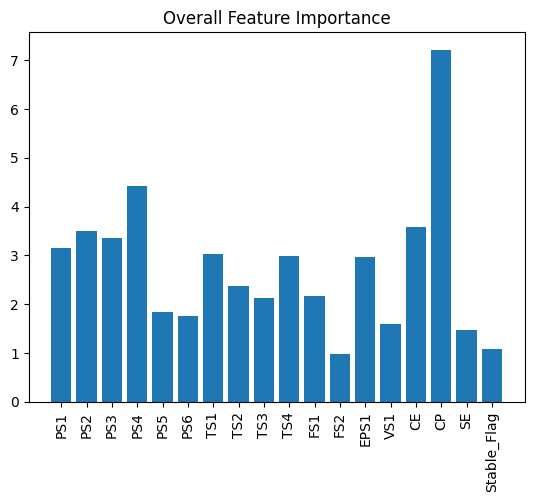

In [28]:
importance = np.mean(np.abs(sgdr.coef_), axis=0)

plt.bar(feature_names, importance)
plt.xticks(rotation=90)
plt.title("Overall Feature Importance")
plt.show()

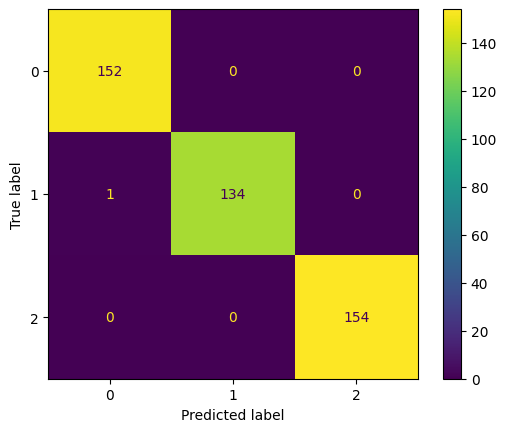

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(sgdr, X_test, y_test)
plt.show()

In [30]:
import tensorflow as tf
from tensorflow.keras import layers

In [74]:
df2 = df.copy()
df2.drop('Stable_Flag', axis=1, inplace=True)

In [75]:
df2_columns = df2.columns
df2_columns = df2_columns.drop(['Cooler_Condition', 'Internal_Pump_Leakage', 'Valve_Condition', 'Hydraulic_Accumulator'])

In [76]:
df2[df2_columns] = scaler.fit_transform(df2[df2_columns])
df2.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,FS2,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator
0,0.040052,0.017452,0.946011,-0.607768,1.178219,1.180667,-1.226838,-1.269472,-1.233673,-1.109099,...,1.458639,0.588187,-0.603614,0.717401,0.195369,0.431929,3.0,100.0,0.0,130.0
1,0.025116,-0.005018,0.885494,-0.607768,0.818900,0.819207,-1.094802,-1.194553,-1.165493,-0.770017,...,1.677960,0.487534,-0.787858,-0.476349,-1.987238,0.451847,3.0,100.0,0.0,130.0
2,-0.029286,-0.044341,0.869570,-0.607768,0.637365,0.634410,-0.944137,-1.071532,-1.077847,-0.627866,...,1.595919,0.330789,-0.610530,-0.784678,-2.498861,0.475014,3.0,100.0,0.0,130.0
3,-0.063262,-0.063204,0.767727,-0.607768,0.478173,0.469669,-0.819201,-0.941500,-0.974301,-0.512727,...,1.454379,0.217183,-0.731146,-0.936623,-2.682422,0.503117,3.0,100.0,0.0,130.0
4,-0.103194,-0.089956,0.672953,-0.607768,0.339211,0.329909,-0.703450,-0.815899,-0.852537,-0.408060,...,1.309819,0.107563,-0.596698,-0.994760,-2.652528,0.465204,3.0,100.0,0.0,130.0


In [77]:
from sklearn.preprocessing import OrdinalEncoder

In [78]:
encoder = OrdinalEncoder()
df2[['Cooler_Condition', 'Valve_Condition', 'Internal_Pump_Leakage', "Hydraulic_Accumulator"]] = encoder.fit_transform(df2[['Cooler_Condition', 'Valve_Condition', 'Internal_Pump_Leakage', "Hydraulic_Accumulator"]])
df2.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,FS2,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator
0,0.040052,0.017452,0.946011,-0.607768,1.178219,1.180667,-1.226838,-1.269472,-1.233673,-1.109099,...,1.458639,0.588187,-0.603614,0.717401,0.195369,0.431929,0.0,3.0,0.0,3.0
1,0.025116,-0.005018,0.885494,-0.607768,0.818900,0.819207,-1.094802,-1.194553,-1.165493,-0.770017,...,1.677960,0.487534,-0.787858,-0.476349,-1.987238,0.451847,0.0,3.0,0.0,3.0
2,-0.029286,-0.044341,0.869570,-0.607768,0.637365,0.634410,-0.944137,-1.071532,-1.077847,-0.627866,...,1.595919,0.330789,-0.610530,-0.784678,-2.498861,0.475014,0.0,3.0,0.0,3.0
3,-0.063262,-0.063204,0.767727,-0.607768,0.478173,0.469669,-0.819201,-0.941500,-0.974301,-0.512727,...,1.454379,0.217183,-0.731146,-0.936623,-2.682422,0.503117,0.0,3.0,0.0,3.0
4,-0.103194,-0.089956,0.672953,-0.607768,0.339211,0.329909,-0.703450,-0.815899,-0.852537,-0.408060,...,1.309819,0.107563,-0.596698,-0.994760,-2.652528,0.465204,0.0,3.0,0.0,3.0


In [79]:
X_scaled = df2.drop(['Cooler_Condition', 'Valve_Condition', 'Internal_Pump_Leakage', 'Hydraulic_Accumulator', "Stable_Flag"], axis=1)
y_scaled = df2[['Cooler_Condition', 'Valve_Condition', 'Internal_Pump_Leakage', 'Hydraulic_Accumulator']]
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

KeyError: "['Stable_Flag'] not found in axis"

In [80]:
print(df2['Cooler_Condition'].value_counts())
print(df2['Valve_Condition'].value_counts())
print(df2['Internal_Pump_Leakage'].value_counts())
print(df2['Hydraulic_Accumulator'].value_counts())

Cooler_Condition
2.0    741
0.0    732
1.0    732
Name: count, dtype: int64
Valve_Condition
3.0    1125
0.0     360
1.0     360
2.0     360
Name: count, dtype: int64
Internal_Pump_Leakage
0.0    1221
2.0     492
1.0     492
Name: count, dtype: int64
Hydraulic_Accumulator
0.0    808
3.0    599
2.0    399
1.0    399
Name: count, dtype: int64


In [81]:
X = df2.drop([
    'Cooler_Condition',
    'Valve_Condition',
    'Internal_Pump_Leakage',
    'Hydraulic_Accumulator'
], axis=1)

y_cooler = df2['Cooler_Condition']
y_valve = df2['Valve_Condition']
y_pump = df2['Internal_Pump_Leakage']
y_acc = df2['Hydraulic_Accumulator']

In [82]:
X_train, X_test, y_cooler_train, y_cooler_test, \
y_valve_train, y_valve_test, \
y_pump_train, y_pump_test, \
y_acc_train, y_acc_test = train_test_split(
    X,
    y_cooler,
    y_valve,
    y_pump,
    y_acc,
    test_size=0.2,
    random_state=42
)

In [83]:
X_train.shape, y_cooler_train.shape, y_valve_train.shape, y_pump_train.shape, y_acc_train.shape

((1764, 17), (1764,), (1764,), (1764,), (1764,))

In [84]:
inputs = tf.keras.Input(shape=(X.shape[1],))

x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(16, activation='relu')(x)

cooler_output = layers.Dense(3, activation='softmax', name='cooler')(x)
valve_output = layers.Dense(4, activation='softmax', name='valve')(x)
pump_output = layers.Dense(3, activation='softmax', name='pump')(x)
acc_output = layers.Dense(4, activation='softmax', name='accumulator')(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=[cooler_output, valve_output, pump_output, acc_output]
)

model.compile(
    optimizer='adam',
    loss={
        'cooler': 'sparse_categorical_crossentropy',
        'valve': 'sparse_categorical_crossentropy',
        'pump': 'sparse_categorical_crossentropy',
        'accumulator': 'sparse_categorical_crossentropy'
    },
    metrics=['accuracy','accuracy','accuracy','accuracy']
)

In [85]:
model.fit(
    X_train,
    {
        'cooler': y_cooler_train,
        'valve': y_valve_train,
        'pump': y_pump_train,
        'accumulator': y_acc_train
    },
    epochs=200,
)

Epoch 1/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accumulator_accuracy: 0.4223 - accumulator_loss: 1.3359 - cooler_accuracy: 0.8475 - cooler_loss: 0.7100 - loss: 4.4641 - pump_accuracy: 0.3265 - pump_loss: 1.0987 - valve_accuracy: 0.4461 - valve_loss: 1.3153
Epoch 2/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accumulator_accuracy: 0.4507 - accumulator_loss: 1.2290 - cooler_accuracy: 0.9552 - cooler_loss: 0.2673 - loss: 3.5967 - pump_accuracy: 0.6111 - pump_loss: 0.8797 - valve_accuracy: 0.5108 - valve_loss: 1.2097
Epoch 3/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accumulator_accuracy: 0.4830 - accumulator_loss: 1.1395 - cooler_accuracy: 0.9966 - cooler_loss: 0.1131 - loss: 3.1088 - pump_accuracy: 0.6361 - pump_loss: 0.7196 - valve_accuracy: 0.5198 - valve_loss: 1.1182
Epoch 4/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accumulator_accuracy: 0.4853 - accumulator_loss: 1.0925 - cooler_accuracy: 0.9983 - cooler_loss: 0.0882 - loss: 2.7922 - pump_accuracy: 0.7749 - pump_loss: 0.532

In [86]:
acc = model.evaluate(X_test, {
        'cooler': y_cooler_test,
        'valve': y_valve_test,
        'pump': y_pump_test,
        'accumulator': y_acc_test
    })
acc

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accumulator_accuracy: 0.8776 - accumulator_loss: 0.3627 - cooler_accuracy: 1.0000 - cooler_loss: 7.5418e-04 - loss: 0.4179 - pump_accuracy: 1.0000 - pump_loss: 0.0017 - valve_accuracy: 0.9841 - valve_loss: 0.0513 


[0.4178566336631775,
 0.000754177279304713,
 0.051274556666612625,
 0.001658095745369792,
 0.3626793324947357,
 0.8775510191917419,
 1.0,
 1.0,
 0.9841269850730896]

In [102]:
data = 2
single_data = X_test.iloc[data:data+1]
single_data

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,FS1,FS2,EPS1,VS1,CE,CP,SE
1468,-0.13095,-0.154919,0.654832,-0.292016,0.792383,0.796012,-0.663594,-0.557566,-0.484339,-0.880235,0.465742,0.145006,0.117957,-0.241764,1.357898,3.333644,0.458943


In [103]:
single_data = single_data.values
single_data

array([[-0.13095026, -0.15491889,  0.6548324 , -0.29201631,  0.79238312,
         0.79601246, -0.66359446, -0.55756561, -0.484339  , -0.88023514,
         0.46574152,  0.14500619,  0.11795681, -0.24176426,  1.35789826,
         3.33364422,  0.45894301]])

In [104]:
pred = model.predict(single_data)
cols = [{
    "component": 'cooler',
    "values": [
        '3 -> close to total failure',
        '20 -> reduced efficiency',
        '100 -> full efficiency'
    ]
},
{
    "component": 'valve',
    "values": [
        '100 -> optimal switching behavior',
        '90 -> small lag',
        '80 -> severe lag',
        '73 -> close to total failure'
    ]
},
{
    "component": 'pump',
    "values": [
        '0 -> no leakage',
        '1 -> weak leakage',
        '2 -> severe leakage'
    ]
}, 
{
    "component": 'accumulator',
    "values": [
        '130 -> optimal pressure',
        '115 -> slightly reduced pressure',
        '100 -> severely reduced pressure',
        '90 -> close to total failure'
    ]
}
]

for i, col in enumerate(cols):
    pred_class = np.argmax(pred[i], axis=1)[0]
    print(f"Predicted {col['component']} condition class: {col['values'][pred_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted cooler condition class: 100 -> full efficiency
Predicted valve condition class: 73 -> close to total failure
Predicted pump condition class: 0 -> no leakage
Predicted accumulator condition class: 130 -> optimal pressure


In [105]:
y_test.iloc[data:data+1]

,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator
1468,2.0,3.0,0.0,0.0


In [91]:
model.save("predictive_maintenance_model.keras")

In [92]:
from tensorflow.keras.models import load_model
loaded_model = load_model("predictive_maintenance_model.keras")
loaded_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │      2,304 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 16)        │        528 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cooler (Dense)      │ (None, 3)         │         51 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ valve (Dense)       │ (None, 4)         │         68 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pump (Dense)        │ (None, 3)         │         51 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ accumulator (Dense) │ (None, 4)         │         68 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,220 (157.11 KB)

 Trainable params: 13,406 (52.37 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26,814 (104.75 KB)

In [93]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [106]:
data = [[-0.13095026, -0.15491889,  0.6548324 , -0.29201631,  0.79238312,
         0.79601246, -0.66359446, -0.55756561, -0.484339  , -0.88023514,
         0.46574152,  0.14500619,  0.11795681, -0.24176426,  1.35789826,
         3.33364422,  0.45894301]]
data = np.array(data)
data.shape

(1, 17)

In [107]:
predictions = model.predict(data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [108]:
for pred in predictions:
    print(int(np.argmax(pred)))

2
3
0
0


In [69]:
arr = np.array([20,10,30,50])
arr[:len(arr) - 1]

array([20, 10, 30])

In [109]:
df2.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,FS2,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator
0,0.040052,0.017452,0.946011,-0.607768,1.178219,1.180667,-1.226838,-1.269472,-1.233673,-1.109099,...,1.458639,0.588187,-0.603614,0.717401,0.195369,0.431929,0.0,3.0,0.0,3.0
1,0.025116,-0.005018,0.885494,-0.607768,0.818900,0.819207,-1.094802,-1.194553,-1.165493,-0.770017,...,1.677960,0.487534,-0.787858,-0.476349,-1.987238,0.451847,0.0,3.0,0.0,3.0
2,-0.029286,-0.044341,0.869570,-0.607768,0.637365,0.634410,-0.944137,-1.071532,-1.077847,-0.627866,...,1.595919,0.330789,-0.610530,-0.784678,-2.498861,0.475014,0.0,3.0,0.0,3.0
3,-0.063262,-0.063204,0.767727,-0.607768,0.478173,0.469669,-0.819201,-0.941500,-0.974301,-0.512727,...,1.454379,0.217183,-0.731146,-0.936623,-2.682422,0.503117,0.0,3.0,0.0,3.0
4,-0.103194,-0.089956,0.672953,-0.607768,0.339211,0.329909,-0.703450,-0.815899,-0.852537,-0.408060,...,1.309819,0.107563,-0.596698,-0.994760,-2.652528,0.465204,0.0,3.0,0.0,3.0


In [110]:
df.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,...,EPS1,VS1,CE,CP,SE,Cooler_Condition,Valve_Condition,Internal_Pump_Leakage,Hydraulic_Accumulator,Stable_Flag
0,160.673492,109.466914,1.991475,0.0,9.842170,9.728098,35.621983,40.978767,38.471017,31.745250,...,2538.929167,0.576950,39.601350,1.862750,59.157183,3.0,100.0,0.0,130.0,1.0
1,160.603320,109.354890,1.976234,0.0,9.635142,9.529488,36.676967,41.532767,38.978967,34.493867,...,2531.498900,0.565850,25.786433,1.255550,59.335617,3.0,100.0,0.0,130.0,1.0
2,160.347720,109.158845,1.972224,0.0,9.530548,9.427949,37.880800,42.442450,39.631950,35.646150,...,2519.928000,0.576533,22.218233,1.113217,59.543150,3.0,100.0,0.0,130.0,1.0
3,160.188088,109.064807,1.946576,0.0,9.438827,9.337430,38.879050,43.403983,40.403383,36.579467,...,2511.541633,0.569267,20.459817,1.062150,59.794900,3.0,100.0,0.0,130.0,1.0
4,160.000472,108.931434,1.922707,0.0,9.358762,9.260636,39.803917,44.332750,41.310550,37.427900,...,2503.449500,0.577367,19.787017,1.070467,59.455267,3.0,100.0,0.0,130.0,1.0


In [114]:
df_test = df.drop(['Cooler_Condition', 'Valve_Condition', 'Internal_Pump_Leakage', 'Hydraulic_Accumulator', "Stable_Flag"], axis=1)
df_test.head()

,PS1,PS2,PS3,PS4,PS5,PS6,TS1,TS2,TS3,TS4,FS1,FS2,EPS1,VS1,CE,CP,SE
0,160.673492,109.466914,1.991475,0.0,9.842170,9.728098,35.621983,40.978767,38.471017,31.745250,6.709815,10.304592,2538.929167,0.576950,39.601350,1.862750,59.157183
1,160.603320,109.354890,1.976234,0.0,9.635142,9.529488,36.676967,41.532767,38.978967,34.493867,6.715315,10.403098,2531.498900,0.565850,25.786433,1.255550,59.335617
2,160.347720,109.158845,1.972224,0.0,9.530548,9.427949,37.880800,42.442450,39.631950,35.646150,6.718522,10.366250,2519.928000,0.576533,22.218233,1.113217,59.543150
3,160.188088,109.064807,1.946576,0.0,9.438827,9.337430,38.879050,43.403983,40.403383,36.579467,6.720565,10.302678,2511.541633,0.569267,20.459817,1.062150,59.794900
4,160.000472,108.931434,1.922707,0.0,9.358762,9.260636,39.803917,44.332750,41.310550,37.427900,6.690308,10.237750,2503.449500,0.577367,19.787017,1.070467,59.455267


In [116]:
df_test.iloc[0:1].values

array([[1.60673492e+02, 1.09466914e+02, 1.99147533e+00, 0.00000000e+00,
        9.84216950e+00, 9.72809750e+00, 3.56219833e+01, 4.09787667e+01,
        3.84710167e+01, 3.17452500e+01, 6.70981500e+00, 1.03045917e+01,
        2.53892917e+03, 5.76950000e-01, 3.96013500e+01, 1.86275000e+00,
        5.91571833e+01]])